Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Loading the dataset

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Initail anaysis of Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.drop(["embarked","class","alive"],axis=1,inplace=True)

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,True


Exploartory Data Analysis(EDA)

In [8]:
null_num=[]
for i in df.columns:
    x=df[i].isnull().sum()
    null_num.append(x)#Sum of null values in each column

In [9]:
null_num

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(177),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(688),
 np.int64(2),
 np.int64(0)]

In [11]:
pd.DataFrame(null_num,index=df.columns,columns=["Total Missing Values"])#Sum of null values in each column in a dataframe format

,Total Missing Values
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
who,0
adult_male,0
deck,688


<Axes: xlabel='deck', ylabel='count'>

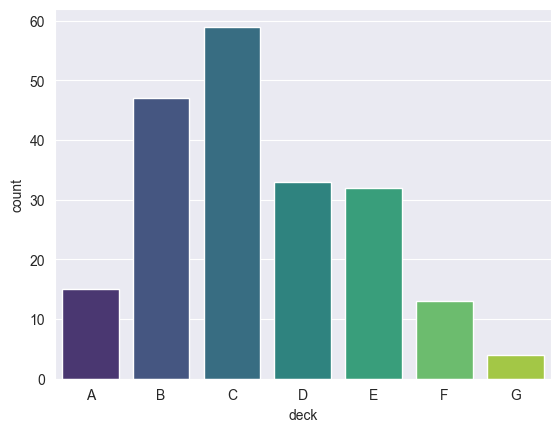

In [12]:
sns.set_style("darkgrid")
sns.countplot(x="deck",data=df,palette="viridis")#Countplot of deck column to see the distribution of passengers in different decks

<Axes: xlabel='deck', ylabel='count'>

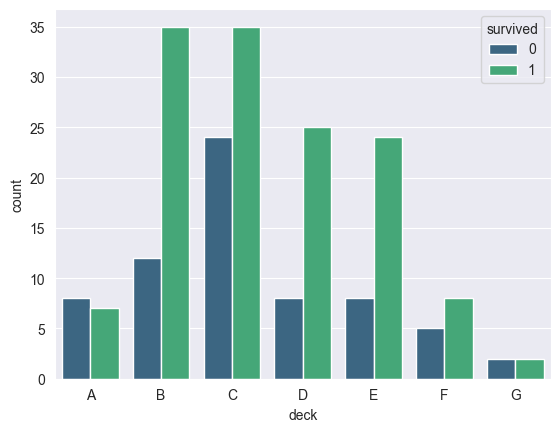

In [13]:
sns.set_style("darkgrid")
sns.countplot(x="deck",hue="survived",data=df,palette="viridis")#Countplot of deck column to see the distribution of passengers in different decks

In [14]:
df.drop(["deck"], axis=1, inplace=True)

<Axes: xlabel='pclass', ylabel='age'>

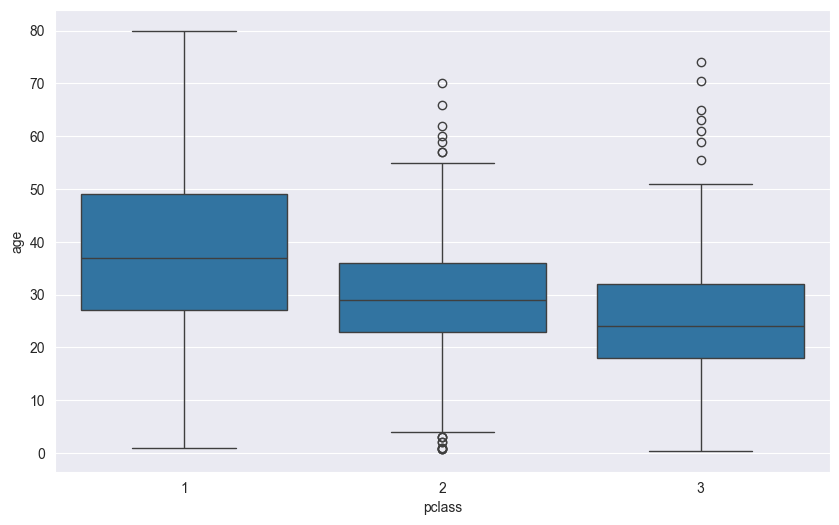

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x="pclass",y="age",data=df)#Boxplot to see the distribution of age across different passenger classes

In [20]:
# Function to fill missing age values based on passenger class
def fillna_age(columns):
    age=columns["age"]
    pclass=columns["pclass"]
    
    if pd.isnull(age):
        if pclass==1:
            return 38
        elif pclass==2:
            return 29
        else:
            return 23
    else:
        return age

In [21]:
df["age"] = df[["age","pclass"]].apply(fillna_age, axis=1)#Applying the function to fill missing age values based on passenger class

In [23]:
null_num=[]
for i in df.columns:
    x=df[i].isnull().sum()
    null_num.append(x)#Sum of null values in each column
pd.DataFrame(null_num,index=df.columns,columns=["Total Missing Values"])#Sum of null values in each column in a dataframe format

,Total Missing Values
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
who,0
adult_male,0
embark_town,2


In [24]:
df.dropna(inplace=True)

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    str    
 3   age          889 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   who          889 non-null    str    
 8   adult_male   889 non-null    bool   
 9   embark_town  889 non-null    str    
 10  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(3)
memory usage: 71.2 KB


<Axes: xlabel='survived', ylabel='count'>

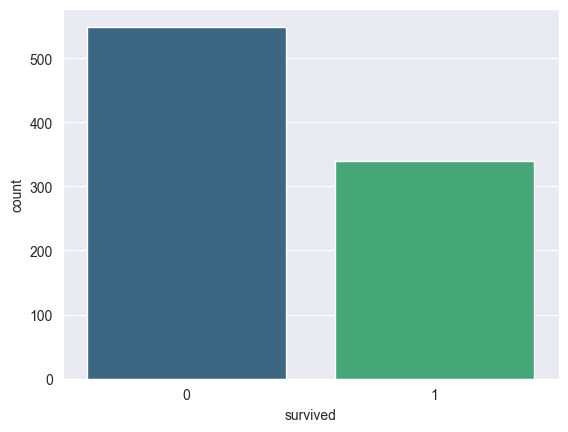

In [26]:
sns.set_style("darkgrid")
sns.countplot(x="survived",data=df,palette="viridis")#Countplot to see the distribution of survived and non-survived passengers

In [27]:
df.survived.value_counts()#Count of survived and non-survived passengers

survived
0    549
1    340
Name: count, dtype: int64

<Axes: xlabel='survived', ylabel='count'>

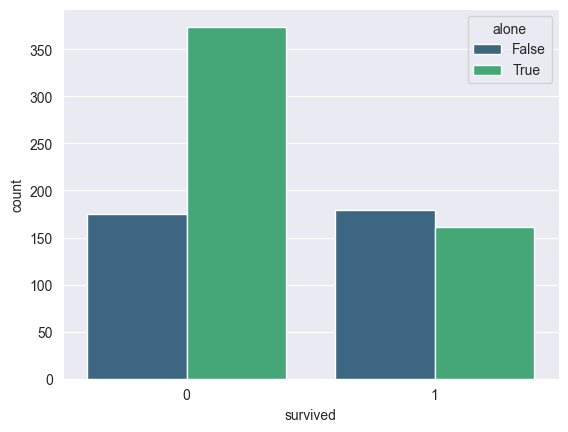

In [28]:
sns.set_style("darkgrid")
sns.countplot(x="survived",hue="alone",data=df,palette="viridis")#Countplot to see the distribution of survived and non-survived passengers based on whether they were alone or not

<Axes: xlabel='survived', ylabel='count'>

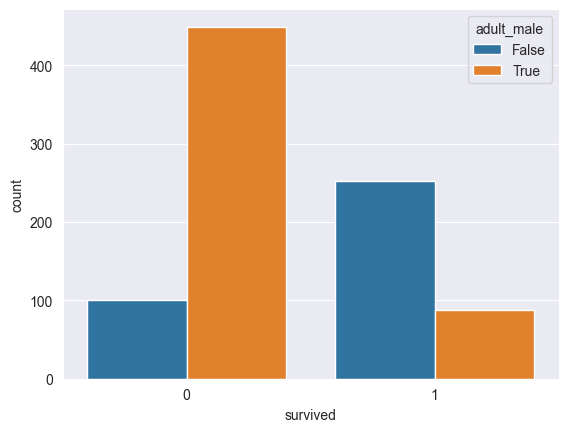

In [30]:
sns.set_style("darkgrid")
sns.countplot(x="survived",hue="adult_male",data=df)#Countplot to see the distribution of survived and non-survived passengers based on whether they were

<Axes: xlabel='survived', ylabel='count'>

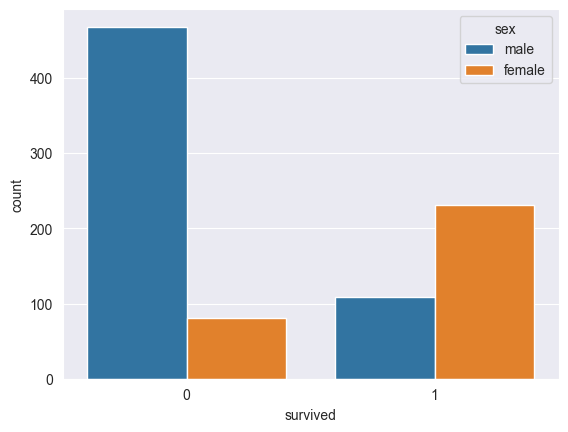

In [31]:
sns.set_style("darkgrid")
sns.countplot(x="survived",hue="sex",data=df)#Countplot to see the distribution of survived and non-survived passengers based

<Axes: xlabel='survived', ylabel='count'>

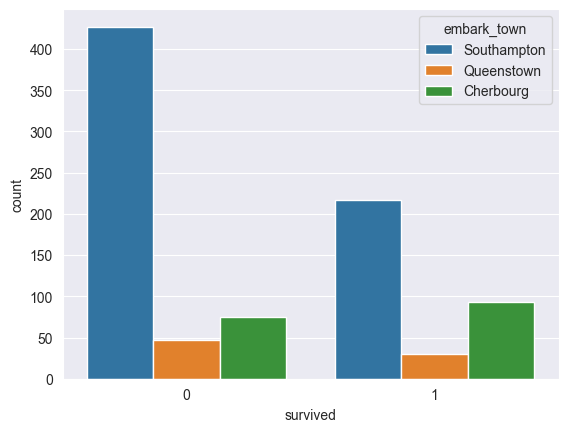

In [32]:
sns.set_style("darkgrid")
sns.countplot(x="survived",hue="embark_town",data=df)#Countplot to see the distribution of survived and non-survived passengers based on their embarkation town

In [33]:
df.embark_town.value_counts()#Count of passengers based on their embarkation town

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

<Axes: xlabel='survived', ylabel='count'>

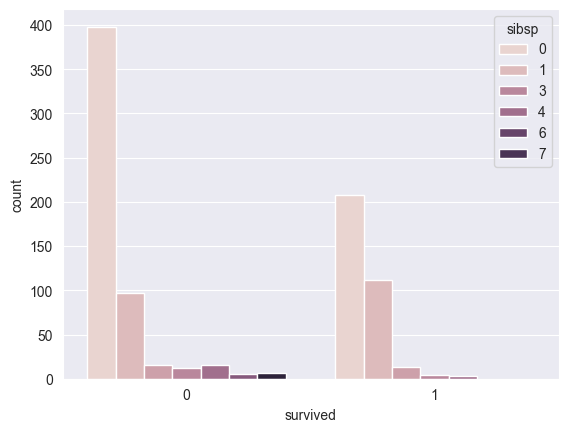

In [34]:
sns.set_style("darkgrid")
sns.countplot(x="survived",hue="sibsp",data=df)#Countplot to see the distribution of survived and non-survived passengers based on the number of siblings/spouses aboard

In [35]:
df.sibsp.value_counts()#Count of passengers based on the number of siblings/spouses aboard

sibsp
0    606
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Examining Numeric Values

<Figure size 1000x600 with 0 Axes>

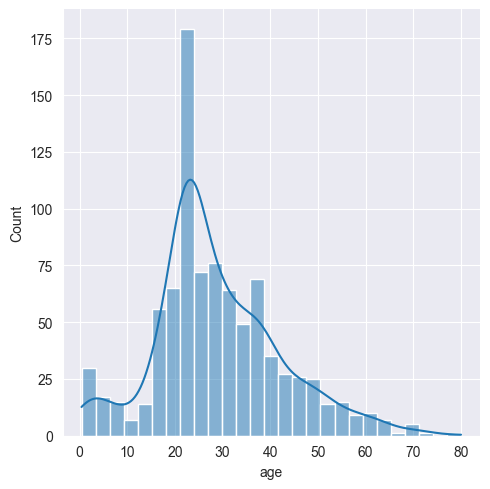

In [36]:
plt.figure(figsize=(10,6))
sns.displot(df["age"],kde=True)#Distribution plot of age to see the distribution of age among passengers

<Figure size 1000x600 with 0 Axes>

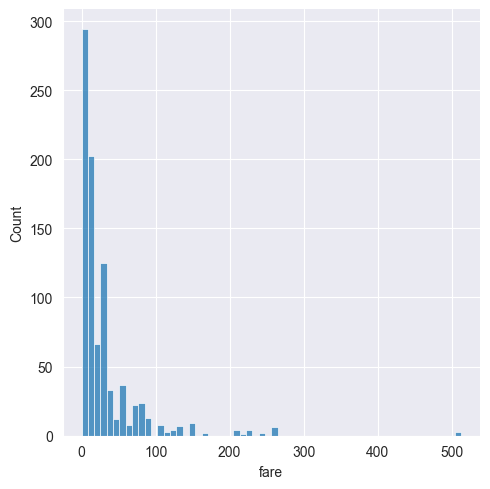

In [38]:
plt.figure(figsize=(10,6))
sns.displot(df["fare"])

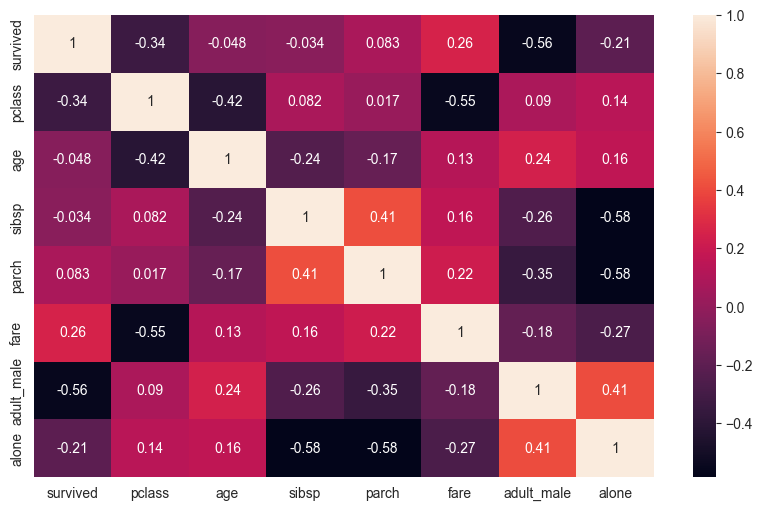

In [40]:
plt.figure(figsize=(10,6))
# Add numeric_only=True here
sns.heatmap(df.corr(numeric_only=True), annot=True) 
plt.show()#Heatmap to see the correlation between numeric features in the dataset

In [41]:
df.drop(["age","sibsp","parch"],axis=1,inplace=True)

In [42]:
df.head()

,survived,pclass,sex,fare,who,adult_male,embark_town,alone
0,0,3,male,7.2500,man,True,Southampton,False
1,1,1,female,71.2833,woman,False,Cherbourg,False
2,1,3,female,7.9250,woman,False,Southampton,True
3,1,1,female,53.1000,woman,False,Southampton,False
4,0,3,male,8.0500,man,True,Southampton,True


In [43]:
sex = pd.get_dummies(df["sex"],drop_first=True)
who = pd.get_dummies(df["who"],drop_first=True)
adult_male = pd.get_dummies(df["adult_male"],drop_first=True)
embark_town = pd.get_dummies(df["embark_town"],drop_first=True)
alone = pd.get_dummies(df["alone"],drop_first=True)

In [44]:
df = pd.concat([df,sex,who,adult_male,embark_town,alone],axis=1)

In [45]:
df.head()

,survived,pclass,sex,fare,who,adult_male,embark_town,alone,male,man,woman,True,Queenstown,Southampton,True
0,0,3,male,7.2500,man,True,Southampton,False,True,True,False,True,False,True,False
1,1,1,female,71.2833,woman,False,Cherbourg,False,False,False,True,False,False,False,False
2,1,3,female,7.9250,woman,False,Southampton,True,False,False,True,False,False,True,True
3,1,1,female,53.1000,woman,False,Southampton,False,False,False,True,False,False,True,False
4,0,3,male,8.0500,man,True,Southampton,True,True,True,False,True,False,True,True


In [46]:
df.drop(["sex","who","adult_male","embark_town","alone"],axis=1,inplace=True)

In [47]:
df.head()

,survived,pclass,fare,male,man,woman,True,Queenstown,Southampton,True
0,0,3,7.2500,True,True,False,True,False,True,False
1,1,1,71.2833,False,False,True,False,False,False,False
2,1,3,7.9250,False,False,True,False,False,True,True
3,1,1,53.1000,False,False,True,False,False,True,False
4,0,3,8.0500,True,True,False,True,False,True,True


Modeling

In [48]:
import sklearn
from sklearn.model_selection import train_test_split

In [50]:
X=df.drop("survived",axis=1)
y=df["survived"]

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)#Splitting the dataset into training and testing sets with a test size of 25% and a random state of 42 for reproducibility

In [52]:
from sklearn.linear_model import LogisticRegression
lr_model= LogisticRegression()#Creating an instance of the Logistic Regression model

In [58]:
# Convert column names for the split data specifically
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Now fit will work
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
y_pred = lr_model.predict(X_test)#Predicting the target variable for the test set using the trained Logistic Regression model

In [61]:
from sklearn.metrics import classification_report,confusion_matrix

In [62]:
print(classification_report(y_test,y_pred))#Classification report to evaluate the performance of the model

              precision    recall  f1-score   support

           0       0.87      0.79      0.83       141
           1       0.68      0.79      0.73        82

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.80      0.79      0.79       223



In [63]:
cnf_matrix=confusion_matrix(y_test,y_pred)#Confusion matrix to evaluate the performance of the model

In [64]:
cnf_matrix

array([[111,  30],
       [ 17,  65]])